## Decision Tree

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_class0 = np.array([[-12, -10], [-14, -6], [-15, 0], [-13, 3], [9,0], [14, -2], [11, -5], [-2, 14], [5, 12], [8, 10]])
X_class1 = np.array([[0, 0],  [1, 6], [5, 4], [3, 0],[-4, 2], [-7, 3], [-8, -6], [2, -6], [1, -8], [4, -8]])

X = np.vstack((X_class0, X_class1))
y = np.hstack((np.zeros(len(X_class0)), np.ones(len(X_class1))))
y = y.astype(int)


# Plota os dados gerados e as linhas de decisão da imagem original
plt.figure(figsize=(8, 6), dpi=200)
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='red', marker='s')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', marker='o')

plt.grid(True, alpha=0.3)
plt.xlabel("feature 0")
plt.ylabel("feature 1")
plt.show()

## Entropy
Slide 11

In [ ]:
import numpy as np

#1 = red, 0 = blue
y_parent = [0]*10 + [1]*10
child_left = [1]*4
child_right = [0]*10 + [1]*6

print(np.unique(y_parent, return_counts=True))
print(np.unique(child_left, return_counts=True))
print(np.unique(child_right, return_counts=True))

#Entropy Right
_, pi = np.unique(child_right, return_counts=True)
pi = pi/np.sum(pi)
sum = 0
for i in pi:
    sum += i*np.log2(i)
print(-sum)

(array([0, 1]), array([10, 10], dtype=int64))
(array([1]), array([4], dtype=int64))
(array([0, 1]), array([10,  6], dtype=int64))
0.954434002924965


# Information Gain with Entropy

In [ ]:
import numpy as np
from scipy.stats import entropy


def entropy_calc(y):
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return entropy(p, base=2)

X_class0 = np.array([[-12, -10], [-14, -6], [-15, 0], [-13, 3], [9,0], [14, -2], [11, -5], [-2, 14], [5, 12], [8, 10]])
X_class1 = np.array([[0, 0],  [1, 6], [5, 4], [3, 0],[-4, 2], [-7, 3], [-8, -6], [2, -6], [1, -8], [4, -8]])

X = np.vstack((X_class0, X_class1))
y = np.hstack((np.zeros(len(X_class0)), np.ones(len(X_class1))))
y = y.astype(int)

th = -12
#Considering feature 0
X_left = X[X[:, 0] <= th]
y_left = y[X[:, 0] <= th]
y_right = y[X[:, 0] > th]
#𝜂
eta = len(X_left)/len(X)

#p
impurity = entropy_calc(y) - (eta * entropy_calc(y_left) + (1 - eta) * entropy_calc(y_right))
print(impurity)


0.2364527976600279


# Split and Information Gain
Slide 14

**Notes:** Observe that this is a simple example. During recursion, both X and Y come from the parent node change.

In [ ]:
import numpy as np
from scipy.stats import entropy

X_class0 = np.array([[-12, -10], [-14, -6], [-15, 0], [-13, 3], [9,0], [14, -2], [11, -5], [-2, 14], [5, 12], [8, 10]])
X_class1 = np.array([[0, 0],  [1, 6], [5, 4], [3, 0],[-4, 2], [-7, 3], [-8, -6], [2, -6], [1, -8], [4, -8]])
X = np.vstack((X_class0, X_class1))
y = np.array([0]*len(X_class0) + [1]*len(X_class1))

m = X.shape[-1]

for feature_i in range(m):
        Xi = X[:, feature_i]
        thresholds = np.unique(Xi)
        for th in thresholds:
                Xi_left = X[X[:, feature_i] <= th]
                yi_left = y[X[:, feature_i] <= th]

                Xi_right = X[X[:, feature_i] > th]
                yi_right = y[X[:, feature_i] > th]


                weight_l = len(Xi_left) / len(X)
                weight_r = len(Xi_right) / len(X)

                h_parent = entropy(np.bincount(y), base=2)#y from parent
                h_child_l = entropy(np.bincount(yi_left), base=2)
                h_child_r  = entropy(np.bincount(yi_right), base=2)

                #Information Gain -- Entropy
                gain = h_parent - (weight_l*h_child_l + weight_r*h_child_r)

                print(f'Gain from feature {feature_i} 𝜏 {th}: [{gain}]')

## Feature Space Partitioning
**Notes:** This figure illustrates individual splits independently and does not account for hierarchical parent splits. 

- Observe the orthogonal partitioning
- In contrast to the slides, the decision tree in scikit-learn evaluates split thresholds that are not necessarily drawn from the set of observed feature values (i.e., thresholds = np.unique(Xi))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

X_class0 = np.array([[-12, -10], [-14, -6], [-15, 0], [-13, 3], [9,0], [14, -2], [11, -5], [-2, 14], [5, 12], [8, 10]])
X_class1 = np.array([[0, 0],  [1, 6], [5, 4], [3, 0],[-4, 2], [-7, 3], [-8, -6], [2, -6], [1, -8], [4, -8]])
X = np.vstack((X_class0, X_class1))
y = np.array([0]*len(X_class0) + [1]*len(X_class1))


clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

plt.figure(figsize=(8, 6))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1],
            color='red', marker='s', label='Class 0')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1],
            color='blue', marker='o', label='Class 1')


tree = clf.tree_

for node in range(tree.node_count):
    feature = tree.feature[node]
    threshold = tree.threshold[node]

    if feature == 0:#Split on feature 0 (x)
        plt.axvline(threshold, linestyle='--', color='black', alpha=0.7)
    elif feature == 1:#Split on feature 0 (x)
        plt.axhline(threshold, linestyle='--', color='black', alpha=0.7)

## Sklearn employs Binary Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X, y)

print(clf.tree_.children_left)
print(clf.tree_.children_right)

tree = clf.tree_

for i in range(tree.node_count):
    if tree.children_left[i] != -1:
        print("nó binário:", i)

[ 1 -1  3 -1 -1]
[ 2 -1  4 -1 -1]
nó binário: 0
nó binário: 2


## Algorithm Overview
Slide 23

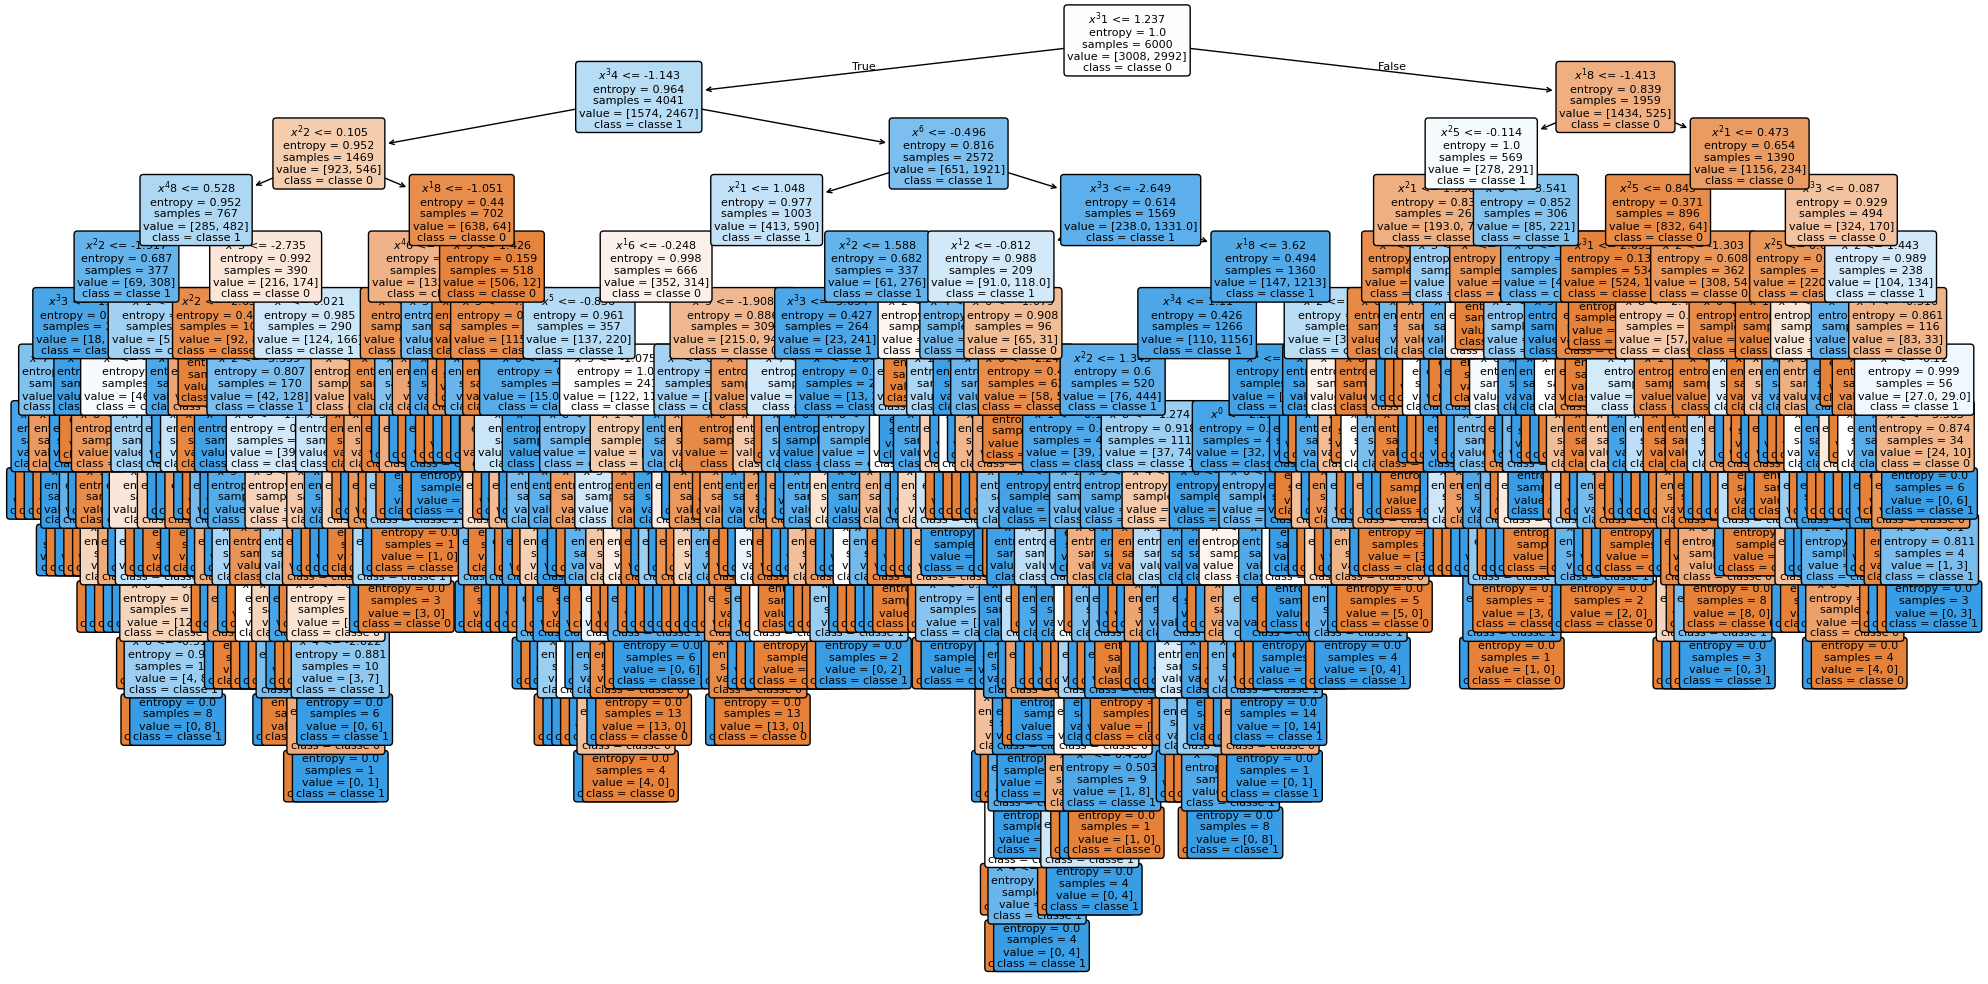

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_blobs, make_classification
from sklearn.tree import plot_tree

seed = 14728
np.random.seed(seed)

#-----------------------Data Option1------------------
X_class0 = np.array([[-12, -10], [-14, -6], [-15, 0], [-13, 3], [9,0], [14, -2], [11, -5], [-2, 14], [5, 12], [8, 10]])
X_class1 = np.array([[0, 0],  [1, 6], [5, 4], [3, 0],[-4, 2], [-7, 3], [-8, -6], [2, -6], [1, -8], [4, -8]])
X = np.vstack((X_class0, X_class1))
y = np.array([0]*len(X_class0) + [1]*len(X_class1))
n_features = X.shape[-1]
n_classes = len(np.unique(y))
#------------------------------------------------------

#-----------------------Data Option2------------------
n, m = 6000, 50
X, y = make_classification(n_samples=n, n_features=m, n_classes=2, n_informative=m//2, random_state=seed)
n_features = X.shape[-1]
n_classes = len(np.unique(y))
#------------------------------------------------------

#criterion{“gini”, “entropy”, “log_loss”}
clf = DecisionTreeClassifier(max_depth=50, random_state=seed, criterion='entropy')
clf.fit(X, y)

plt.figure(figsize=(20,10))
plot_tree(
    clf,
    filled=True,
    rounded=True,
    feature_names=[rf'$x^{i}$' for i in range(n_features)],
    class_names=['classe '+str(i) for i in range(n_classes)],
    fontsize=8
)

plt.tight_layout()
plt.savefig("DT.pdf", bbox_inches='tight', pad_inches=0)
plt.show()


## Leaf Nodes

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
import numpy as np

X, y = load_breast_cancer(return_X_y=True)

clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X, y)

tree = clf.tree_

for node in range(tree.node_count):
    nk = tree.value[node]
    y = np.argmax(nk)
    print(nk, y)


[[0.37258348 0.62741652]] 1
[[0.08707124 0.91292876]] 1
[[0.01501502 0.98498498]] 1
[[0.60869565 0.39130435]] 0
[[0.94210526 0.05789474]] 0
[[0.47058824 0.52941176]] 1
[[0.98843931 0.01156069]] 0


## Decision Boundary

Non-linear surface

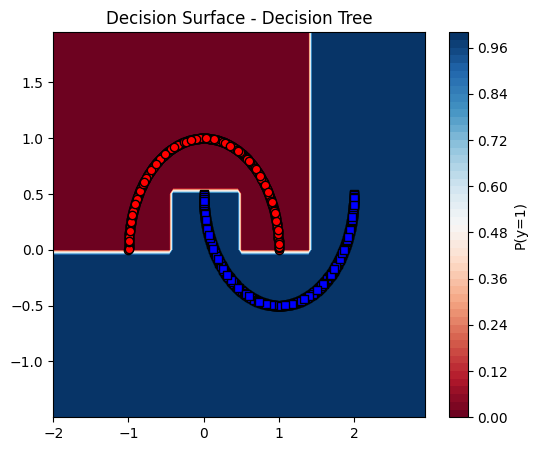

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons


np.random.seed(0)
n, m = 1000, 2
X, y = make_moons(n_samples=n)
n_features = X.shape[-1]
n_classes = len(np.unique(y))

model = DecisionTreeClassifier(max_depth=None)
model.fit(X, y)

# meshgrid
h = 0.05
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))
grid = np.c_[xx.ravel(), yy.ravel()]

prob = model.predict_proba(grid)[:,1]

Z = prob.reshape(xx.shape)

# Plot degradê (surface)
plt.figure(figsize=(6,5))
plt.contourf(xx,yy,Z,levels=50,cmap='RdBu')
plt.colorbar(label="P(y=1)")
plt.scatter(X[y==0, 0], X[y==0, 1],c='red', marker='o',edgecolors='k')
plt.scatter(X[y==1, 0],X[y==1, 1],c='blue',marker='s',edgecolors='k')

plt.title("Decision Surface - Decision Tree")
plt.show()